# loading the dataset

In [45]:
from pathlib import Path
import pandas as pd

file_dir = Path("../data")

df = pd.read_csv("../data/train.csv")

df.head(5)

,row_id,household_id,date,num_residents,home_sqft,has_ev,has_solar,has_pool,heating_type,hvac_age_years,...,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
0,0,H00000,2025-01-02,4,1654,0,0,0,electric,25,...,-2.0,70,12.9,0.0,7.4,0,0,29.11,29.110000,32.91
1,1,H00000,2025-01-03,4,1654,0,0,0,electric,25,...,-3.9,37,10.1,0.0,6.3,0,0,32.91,31.010000,27.97
2,2,H00000,2025-01-04,4,1654,0,0,0,electric,25,...,-4.5,92,9.9,0.0,7.2,1,0,27.97,29.996667,30.81
3,3,H00000,2025-01-05,4,1654,0,0,0,electric,25,...,-3.1,65,15.1,0.0,3.3,1,0,30.81,30.200000,32.56
4,4,H00000,2025-01-06,4,1654,0,0,0,electric,25,...,-3.8,71,17.0,10.2,7.2,0,0,32.56,30.672000,31.93


<!-- exploring dataset -->

# analyzing the data

In [26]:
df.describe()

,row_id,num_residents,home_sqft,has_ev,has_solar,has_pool,hvac_age_years,temp_avg_c,temp_min_c,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
count,88500.00000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000
mean,54742.50000,3.489333,2622.456667,0.208667,0.178667,0.116000,13.184000,-0.402393,-3.904333,3.099979,59.975977,9.986673,1.417172,5.489279,0.288136,0.033898,26.109988,26.081123,26.064483
std,31610.10339,1.705458,1094.704175,0.406358,0.383075,0.320227,7.338943,4.950384,5.024928,5.026448,14.974369,6.310223,3.204005,2.144253,0.452897,0.180968,8.792819,7.655410,8.785717
min,0.00000,1.000000,709.000000,0.000000,0.000000,0.000000,1.000000,-18.700000,-23.500000,-15.700000,10.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.400000,2.362857,0.400000
25%,27371.25000,2.000000,1679.750000,0.000000,0.000000,0.000000,7.000000,-3.800000,-7.300000,-0.300000,50.000000,5.300000,0.000000,4.000000,0.000000,0.000000,20.300000,21.061607,20.260000
50%,54742.50000,3.500000,2707.500000,0.000000,0.000000,0.000000,13.000000,-0.600000,-4.000000,2.900000,60.000000,8.700000,0.000000,5.500000,0.000000,0.000000,25.310000,25.542857,25.260000
75%,82113.75000,5.000000,3513.250000,0.000000,0.000000,0.000000,20.000000,2.800000,-0.600000,6.400000,70.000000,13.300000,1.100000,7.000000,1.000000,0.000000,31.180000,30.732976,31.130000
max,109485.00000,6.000000,4498.000000,1.000000,1.000000,1.000000,25.000000,19.400000,16.300000,23.600000,99.000000,59.800000,46.600000,10.000000,1.000000,1.000000,76.200000,58.521429,76.200000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88500 entries, 0 to 88499
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   row_id              88500 non-null  int64  
 1   household_id        88500 non-null  object 
 2   date                88500 non-null  object 
 3   num_residents       88500 non-null  int64  
 4   home_sqft           88500 non-null  int64  
 5   has_ev              88500 non-null  int64  
 6   has_solar           88500 non-null  int64  
 7   has_pool            88500 non-null  int64  
 8   heating_type        88500 non-null  object 
 9   hvac_age_years      88500 non-null  int64  
 10  temp_avg_c          88500 non-null  float64
 11  temp_min_c          88500 non-null  float64
 12  temp_max_c          88500 non-null  float64
 13  humidity_pct        88500 non-null  int64  
 14  wind_kph            88500 non-null  float64
 15  precip_mm           88500 non-null  float64
 16  sola

In [ ]:
# df.drop(columns=["row_id"], inplace = True)

In [46]:
df['date'] = pd.to_datetime(df['date'])
df['date']

0       2025-01-02
1       2025-01-03
2       2025-01-04
3       2025-01-05
4       2025-01-06
           ...    
88495   2025-02-25
88496   2025-02-26
88497   2025-02-27
88498   2025-02-28
88499   2025-03-01
Name: date, Length: 88500, dtype: datetime64[ns]

# sorting the data based on date 

In [182]:
df = df.sort_values(["date", "household_id"])
df.reset_index(drop = True, inplace = True)

df

,household_id,date,num_residents,home_sqft,has_ev,has_solar,has_pool,heating_type,hvac_age_years,temp_avg_c,...,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
0,H00000,2025-01-02,4,1654,0,0,0,electric,25,-6.5,...,-2.0,70,12.9,0.0,7.4,0,0,29.11,29.110000,32.91
1,H00001,2025-01-02,4,750,0,0,0,gas,6,-2.8,...,1.9,61,3.2,5.3,4.4,0,0,23.06,23.425000,18.40
2,H00002,2025-01-02,1,2278,0,0,0,electric,12,-6.1,...,-3.7,66,3.9,0.0,2.6,0,0,27.13,15.248333,21.19
3,H00003,2025-01-02,6,1206,0,0,0,heat_pump,19,-4.2,...,-2.0,30,15.4,0.0,5.4,0,0,36.53,27.176667,28.94
4,H00004,2025-01-02,5,4035,1,0,0,heat_pump,8,-1.7,...,0.9,34,2.2,0.0,6.4,0,0,43.20,24.313333,47.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88495,H01495,2025-03-01,4,1123,0,0,0,electric,14,3.6,...,7.2,84,9.1,0.4,6.6,1,0,22.28,24.462857,21.34
88496,H01496,2025-03-01,1,4319,0,1,0,heat_pump,22,3.9,...,6.0,69,2.3,0.0,4.1,1,0,18.25,16.275714,16.38
88497,H01497,2025-03-01,1,1209,0,0,0,gas,21,5.0,...,8.8,30,7.3,0.0,8.2,1,0,10.39,13.041429,15.74
88498,H01498,2025-03-01,6,4048,0,0,0,gas,18,3.7,...,5.8,47,22.0,0.0,3.2,1,0,26.81,29.018571,28.46


In [183]:
df.isnull().sum()

household_id          0
date                  0
num_residents         0
home_sqft             0
has_ev                0
has_solar             0
has_pool              0
heating_type          0
hvac_age_years        0
temp_avg_c            0
temp_min_c            0
temp_max_c            0
humidity_pct          0
wind_kph              0
precip_mm             0
solar_index           0
is_weekend            0
is_holiday            0
prior_day_kwh         0
prior_week_avg_kwh    0
kwh                   0
dtype: int64

## converting the datatype of some columns to int as they represents as binary

In [121]:
df['has_ev'] = df['has_ev'].astype(dtype = 'int64')
df['has_solar'] = df['has_solar'].astype(dtype = 'int64')
df['has_pool'] = df['has_pool'].astype(dtype = 'int64')
df['num_residents'] = df['num_residents'].astype(dtype = 'int64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88500 entries, 0 to 88499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   household_id        88500 non-null  object        
 1   date                88500 non-null  datetime64[ns]
 2   num_residents       88500 non-null  int64         
 3   home_sqft           88500 non-null  int64         
 4   has_ev              88500 non-null  int64         
 5   has_solar           88500 non-null  int64         
 6   has_pool            88500 non-null  int64         
 7   heating_type        88500 non-null  object        
 8   hvac_age_years      88500 non-null  int64         
 9   temp_avg_c          88500 non-null  float64       
 10  temp_min_c          88500 non-null  float64       
 11  temp_max_c          88500 non-null  float64       
 12  humidity_pct        88500 non-null  int64         
 13  wind_kph            88500 non-null  float64   

In [111]:
df

,household_id,date,num_residents,home_sqft,has_ev,has_solar,has_pool,heating_type,hvac_age_years,temp_avg_c,...,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
0,H00000,2025-01-02,4,1654,0,0,0,electric,25,-6.5,...,-2.0,70,12.9,0.0,7.4,0,0,29.11,29.110000,32.91
1,H00000,2025-01-03,4,1654,0,0,0,electric,25,-6.5,...,-3.9,37,10.1,0.0,6.3,0,0,32.91,31.010000,27.97
2,H00000,2025-01-04,4,1654,0,0,0,electric,25,-6.7,...,-4.5,92,9.9,0.0,7.2,1,0,27.97,29.996667,30.81
3,H00000,2025-01-05,4,1654,0,0,0,electric,25,-7.0,...,-3.1,65,15.1,0.0,3.3,1,0,30.81,30.200000,32.56
4,H00000,2025-01-06,4,1654,0,0,0,electric,25,-7.3,...,-3.8,71,17.0,10.2,7.2,0,0,32.56,30.672000,31.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88495,H01499,2025-02-25,4,1663,0,0,0,gas,22,-1.2,...,3.3,71,10.4,0.0,7.8,0,0,15.97,19.597143,22.94
88496,H01499,2025-02-26,4,1663,0,0,0,gas,22,-1.5,...,1.3,69,8.3,0.0,5.0,0,0,22.94,20.372857,17.61
88497,H01499,2025-02-27,4,1663,0,0,0,gas,22,-1.6,...,0.7,61,6.8,6.0,4.3,0,0,17.61,20.041429,25.88
88498,H01499,2025-02-28,4,1663,0,0,0,gas,22,-2.0,...,1.3,73,2.6,0.0,6.3,0,0,25.88,20.638571,20.91


In [110]:
df.duplicated().sum()

np.int64(0)

# checking whether data is biased or unbaised

In [114]:
df['heating_type'].unique()

count_ = df.groupby('heating_type')['heating_type'].count()

count_

heating_type
electric     30975
gas          34692
heat_pump    22833
Name: heating_type, dtype: int64

In [116]:
df.select_dtypes(include="number").describe()

,num_residents,home_sqft,has_ev,has_solar,has_pool,hvac_age_years,temp_avg_c,temp_min_c,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
count,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000,88500.000000
mean,3.489333,2622.456667,0.208667,0.178667,0.116000,13.184000,-0.402393,-3.904333,3.099979,59.975977,9.986673,1.417172,5.489279,0.288136,0.033898,26.109988,26.081123,26.064483
std,1.705458,1094.704175,0.406358,0.383075,0.320227,7.338943,4.950384,5.024928,5.026448,14.974369,6.310223,3.204005,2.144253,0.452897,0.180968,8.792819,7.655410,8.785717
min,1.000000,709.000000,0.000000,0.000000,0.000000,1.000000,-18.700000,-23.500000,-15.700000,10.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.400000,2.362857,0.400000
25%,2.000000,1679.750000,0.000000,0.000000,0.000000,7.000000,-3.800000,-7.300000,-0.300000,50.000000,5.300000,0.000000,4.000000,0.000000,0.000000,20.300000,21.061607,20.260000
50%,3.500000,2707.500000,0.000000,0.000000,0.000000,13.000000,-0.600000,-4.000000,2.900000,60.000000,8.700000,0.000000,5.500000,0.000000,0.000000,25.310000,25.542857,25.260000
75%,5.000000,3513.250000,0.000000,0.000000,0.000000,20.000000,2.800000,-0.600000,6.400000,70.000000,13.300000,1.100000,7.000000,1.000000,0.000000,31.180000,30.732976,31.130000
max,6.000000,4498.000000,1.000000,1.000000,1.000000,25.000000,19.400000,16.300000,23.600000,99.000000,59.800000,46.600000,10.000000,1.000000,1.000000,76.200000,58.521429,76.200000


In [123]:
df.select_dtypes(include="object").describe()

,household_id,heating_type
count,88500,88500
unique,1500,3
top,H01499,gas
freq,59,34692


# checking whether every household id contains exact same rows 

In [127]:
df.groupby('household_id')['household_id'].count().unique()

array([59])

# analyzing the column which are going to act as label or predict column

In [128]:
df['kwh'].describe()

count    88500.000000
mean        26.064483
std          8.785717
min          0.400000
25%         20.260000
50%         25.260000
75%         31.130000
max         76.200000
Name: kwh, dtype: float64

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

## using hist plot, plotting all the columns with respect to count and analyzing values frequency 

array([[<Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'num_residents'}>,
        <Axes: title={'center': 'home_sqft'}>,
        <Axes: title={'center': 'has_ev'}>],
       [<Axes: title={'center': 'has_solar'}>,
        <Axes: title={'center': 'has_pool'}>,
        <Axes: title={'center': 'hvac_age_years'}>,
        <Axes: title={'center': 'temp_avg_c'}>],
       [<Axes: title={'center': 'temp_min_c'}>,
        <Axes: title={'center': 'temp_max_c'}>,
        <Axes: title={'center': 'humidity_pct'}>,
        <Axes: title={'center': 'wind_kph'}>],
       [<Axes: title={'center': 'precip_mm'}>,
        <Axes: title={'center': 'solar_index'}>,
        <Axes: title={'center': 'is_weekend'}>,
        <Axes: title={'center': 'is_holiday'}>],
       [<Axes: title={'center': 'prior_day_kwh'}>,
        <Axes: title={'center': 'prior_week_avg_kwh'}>,
        <Axes: title={'center': 'kwh'}>, <Axes: >]], dtype=object)

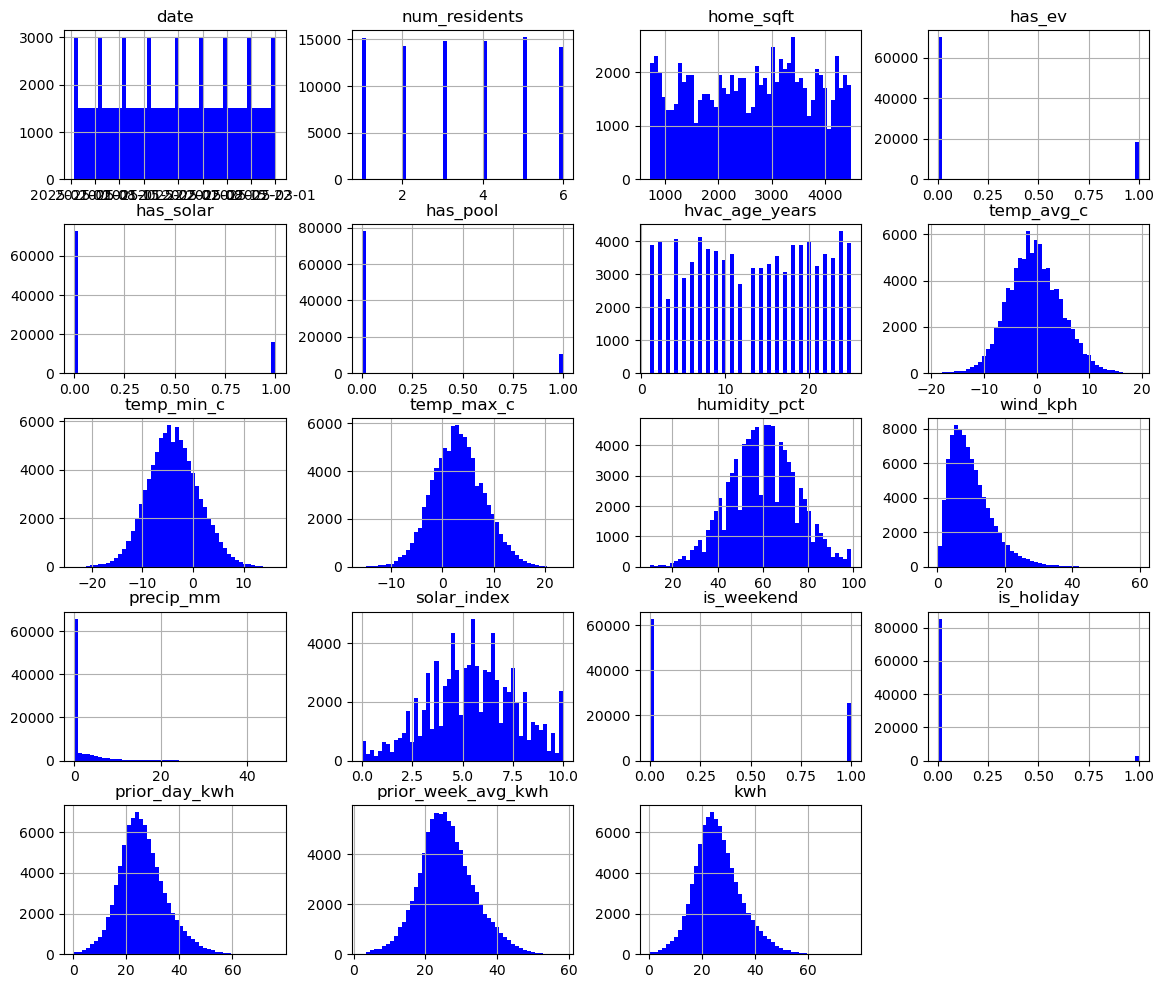

In [174]:
df.hist(bins = 50, figsize = (14,12), color = 'blue')

## hist plot -> kwh lies mostly in range 10-40 

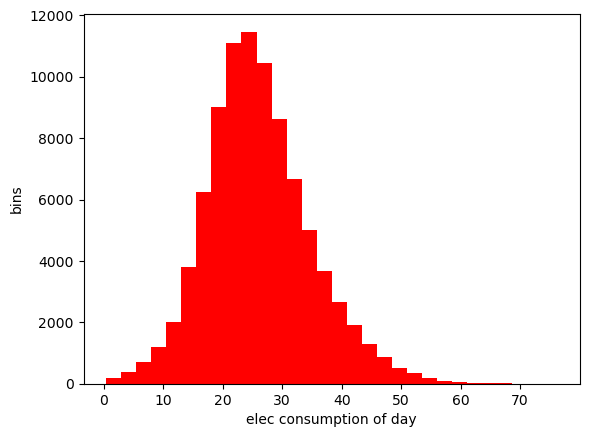

In [132]:
plt.hist(df['kwh'], bins = 30, color = 'red')
plt.xlabel("elec consumption of day")
plt.ylabel("bins")
plt.show()

# using boxplot to check the outliers in kwh

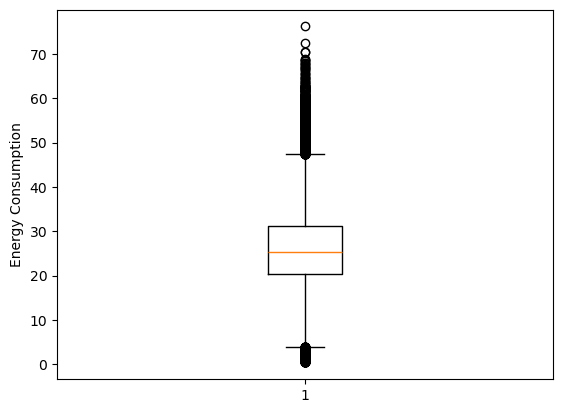

In [131]:
plt.boxplot(df["kwh"])
plt.ylabel("Energy Consumption")
plt.show()

# analyzing the outliers how much contains if less count we can omit 
- ### kwh cannot -ve so if outliers contain -ve -> should have omit

In [155]:
outlier1 = df.query("kwh < 2")['kwh'].count()
outlier2 = df.query("kwh > 60")['kwh'].count()
kwh_max = df['kwh'].max()

print(f"count kwh less than 2 --> {outlier1}")
print(f"count kwh greater than 60 --> {outlier2}")
print(f"max kwh --> {kwh_max}")

count kwh less than 2 --> 102
count kwh greater than 60 --> 86
max kwh --> 76.2


In [199]:
outliers = df[(df["kwh"] < 2) | (df["kwh"] > 60)]

outliers[[
    "kwh",
    "num_residents",
    "home_sqft",
    "has_ev",
    "has_solar",
    "has_pool",
    "hvac_age_years",
    "temp_avg_c"
]].sort_values("kwh")

,kwh,num_residents,home_sqft,has_ev,has_solar,has_pool,hvac_age_years,temp_avg_c
9430,0.40,1,1000,0,1,0,2,-2.5
74891,0.42,3,867,0,1,0,6,9.2
6430,0.43,1,1000,0,1,0,2,-1.3
65120,0.44,1,1137,0,1,0,14,-2.5
38478,0.44,2,999,0,1,0,1,3.2
...,...,...,...,...,...,...,...,...
4412,68.76,1,4456,1,0,0,15,-6.3
44385,70.48,6,3581,1,0,0,20,-2.1
72612,70.48,6,3122,1,0,1,19,0.9
19781,72.38,6,3540,1,0,1,24,-4.6


# using corr to check the relationship between dependent variable and independent variable
- ## assume if we use linear model so to check predict column  is depend most on which column

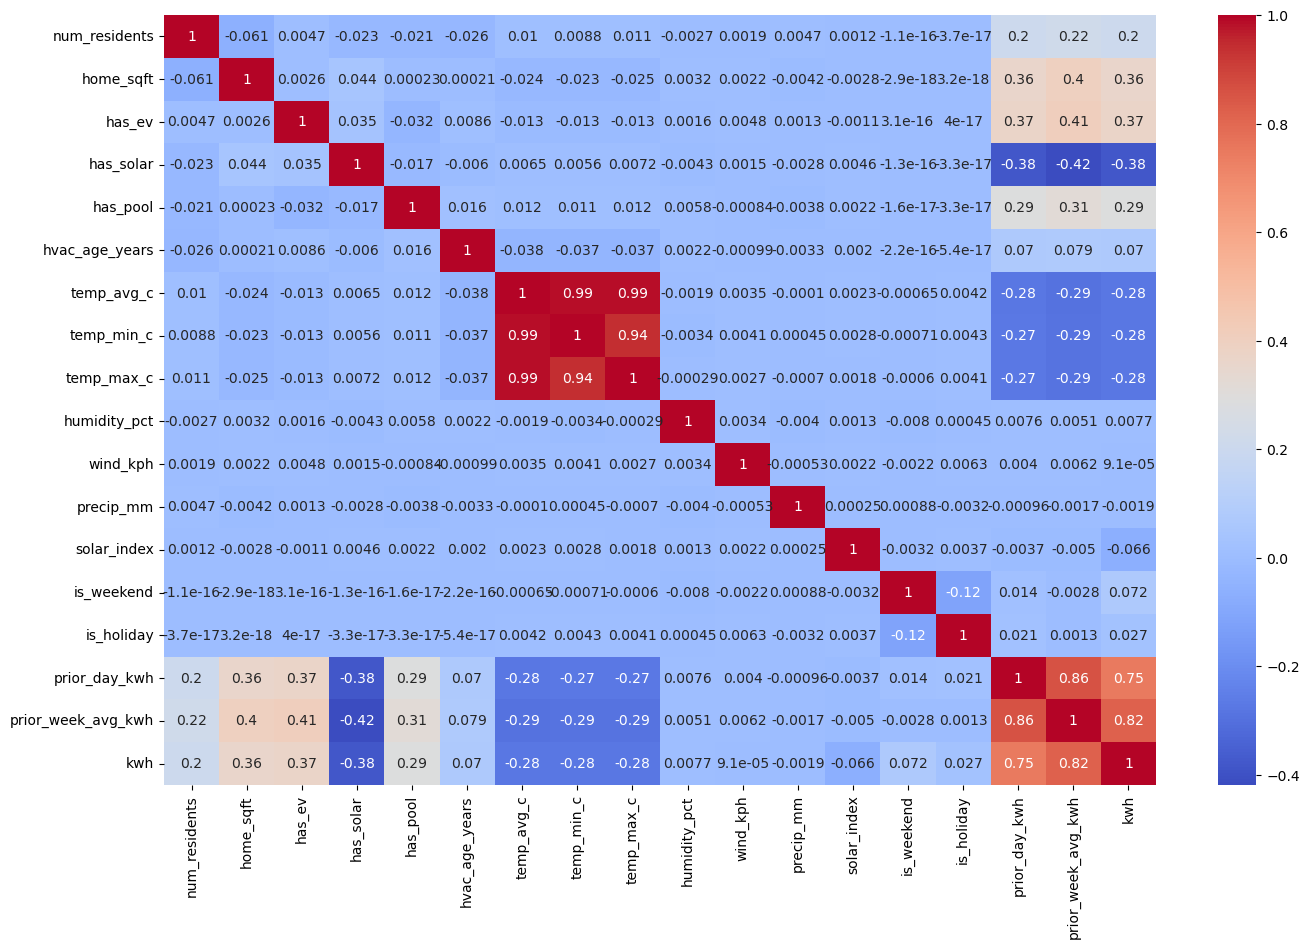

In [166]:
corr = df.select_dtypes(include="number").corr()

fig = plt.figure(figsize = (16, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

plt.show()

# plotting features with kwh 

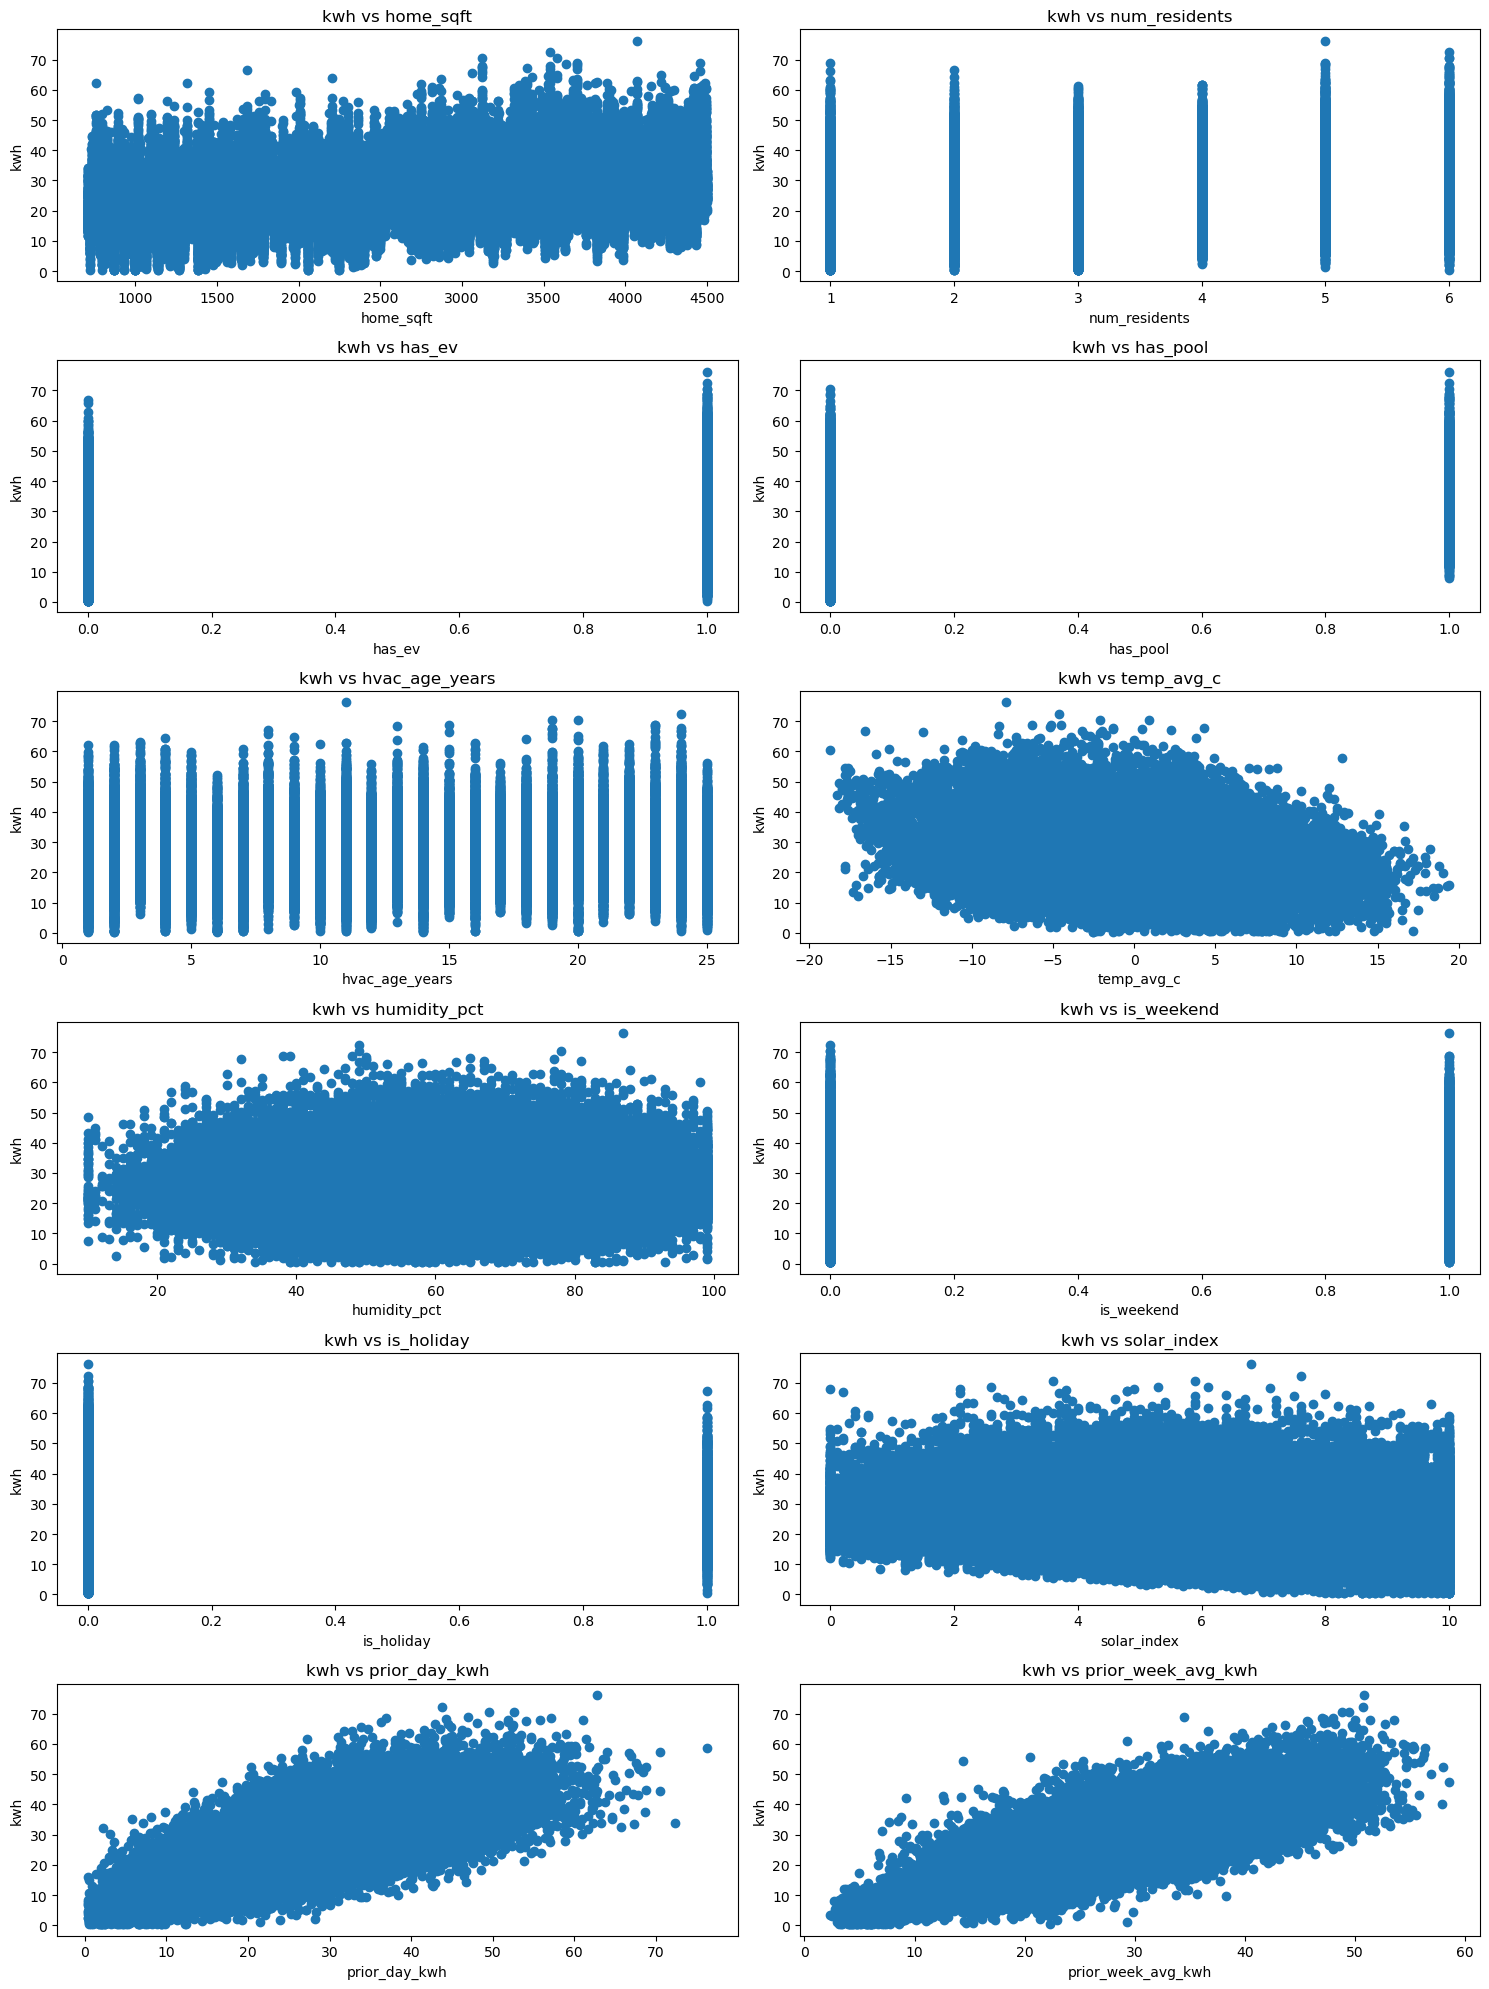

In [198]:
features = [
    "home_sqft",
    "num_residents",
    "has_ev",
    "has_pool",
    "hvac_age_years",
    "temp_avg_c",
    "humidity_pct",
    "is_weekend",
    "is_holiday",
    "solar_index",
    "prior_day_kwh", 
    "prior_week_avg_kwh"
]

fig, ax = plt.subplots(6, 2, figsize = (15, 20))

for i, feature in enumerate(features):

    row = i // 2
    col = i % 2
    
    ax[row, col].scatter( df[feature] , df['kwh'] )
    ax[row, col].set_xlabel(feature)
    ax[row, col].set_ylabel("kwh")
    ax[row, col].set_title(f"kwh vs {feature}")

plt.tight_layout()
plt.show()

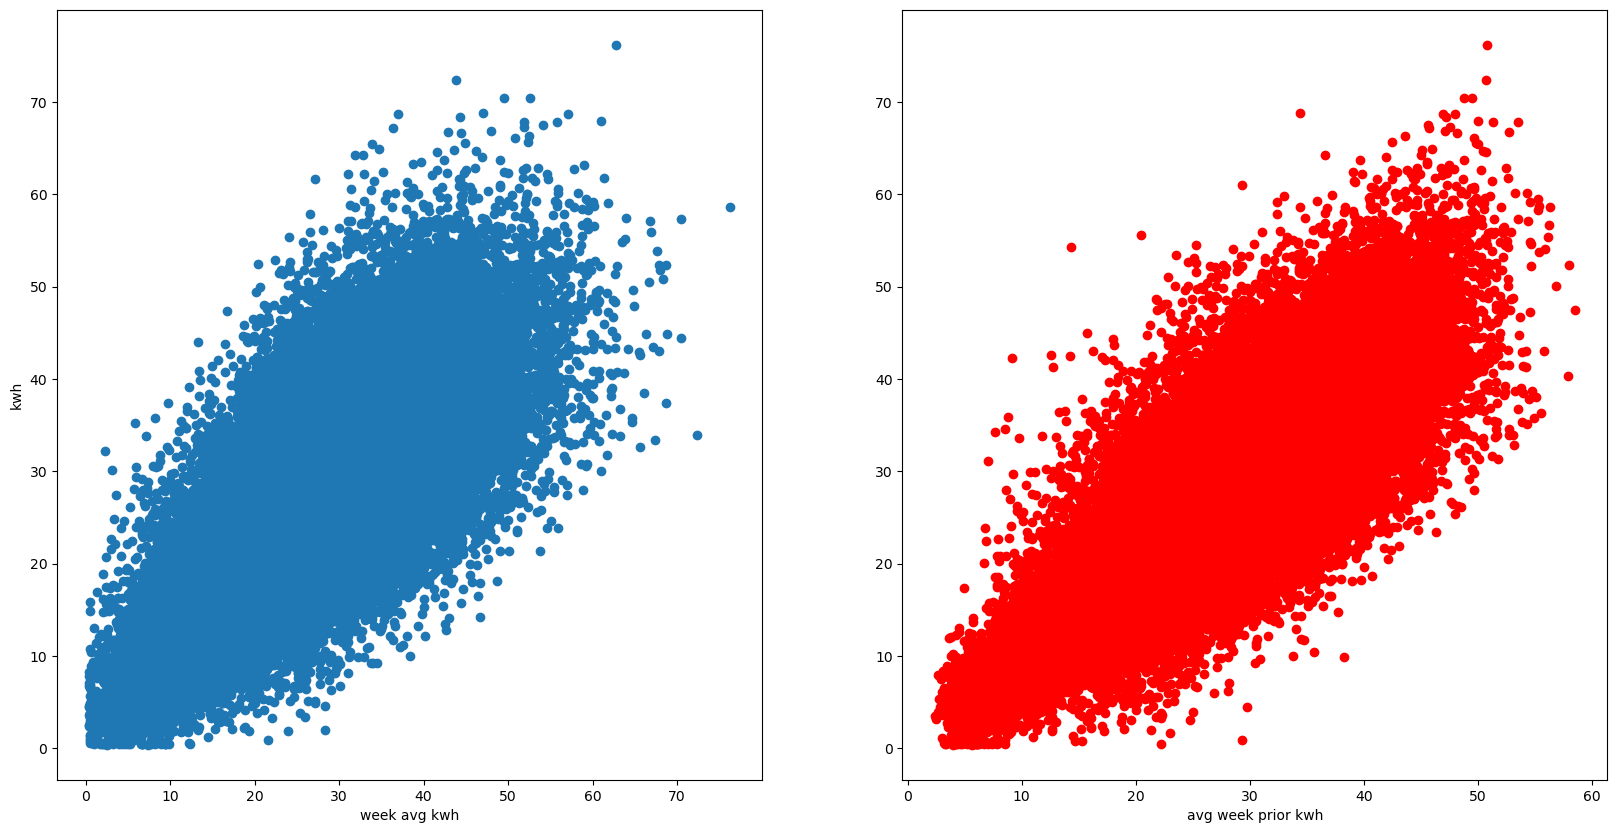

In [173]:
x = df['prior_day_kwh']
y = df['kwh']

fig, ax = plt.subplots(1, 2, figsize = (20, 10))

ax[0].scatter(x, y)
ax[0].set_xlabel("week avg kwh")
ax[0].set_ylabel("kwh")

ax[1].scatter(df['prior_week_avg_kwh'], df['kwh'], color = 'red')
ax[1].set_xlabel("avg week prior kwh")

plt.show()

# analyzing single household id 

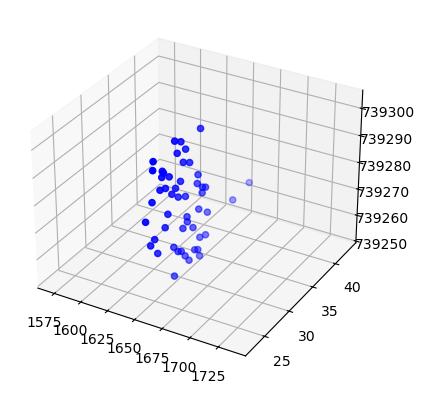

In [103]:

x = df.loc[:50, 'home_sqft']
y = df.loc[ :50, 'kwh']
z = df.loc[ :50, 'date'].map(pd.Timestamp.toordinal)

ax = plt.axes(projection ='3d')

ax.scatter(x, y, z,  color = 'blue')
# ax.xlabel('home_sqft')
# ax.ylabel('elec consumption')
# ax.legend()

plt.show()

Text(0, 0.5, 'elec consumption')

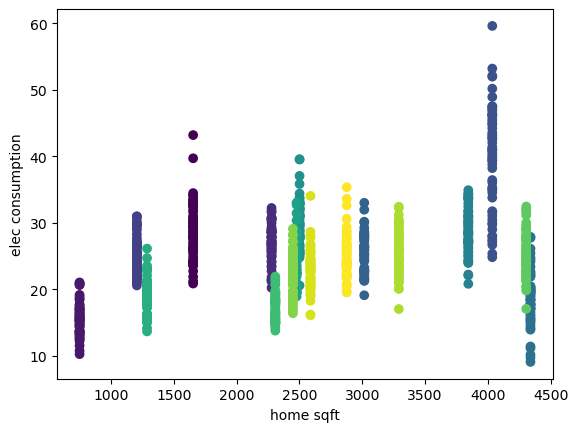

In [105]:
count = 1000

x = df.loc[:count, 'home_sqft']
y = df.loc[ :count, 'kwh']

home = df.loc[ :count, 'household_id'].astype('category').cat.codes

plt.scatter(x, y, c = home, cmap = 'viridis')
plt.xlabel("home sqft")
plt.ylabel("elec consumption")
# plt.legend()

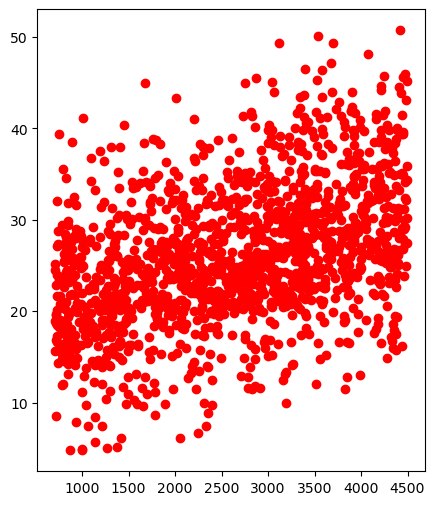

In [209]:
kwh_per_house = df.groupby("household_id")['kwh'].mean()
# perhouse_sqft = df[["household_id", "home_sqft"]].drop_duplicates()
house_sqft = df.groupby("household_id")["home_sqft"].unique()

x = house_sqft
y = kwh_per_house

fig = plt.figure(figsize=(5, 6))
# plt.plot(x, y)
plt.scatter(x, y, color = 'red')

plt.show()

# dumping train.csv after cleaning and analyzing

In [212]:
from pathlib import Path

file_dir = Path("../data")

df.to_csv( file_dir/"clean_train.csv", index = False)